# **Loading the Dataset**

In [2]:
import pandas as pd
import numpy as np
df=pd.read_csv('/content/sample_data/train_loan.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## **Getting the info of our dataset**

### **From the info, it seems like we have so many missing values**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


### **Checking for duplicates, it seems like the data don't have any duplicates**

In [4]:
df.duplicated().sum()

np.int64(0)

# **Preprocessing Steps**

## **Handling Missing values**

###**Getting the percentage of our missing values to decide if we want to drop the entire columns or rows or perform imputations**

In [5]:
round(df.isnull().mean()*100,2)

,0
Loan_ID,0.00
Gender,2.12
Married,0.49
Dependents,2.44
Education,0.00
Self_Employed,5.21
ApplicantIncome,0.00
CoapplicantIncome,0.00
LoanAmount,3.58
Loan_Amount_Term,2.28


### **Based on the data, we can just perform imputations on the missing values**

### **The missing values of the categorical columns are being replaced with the mode**

In [6]:
categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

### **The missing values of the numerical columns are being replaced with the median**

In [7]:
numerical_cols=['LoanAmount','Loan_Amount_Term']
for col in numerical_cols:
  df[col]=df[col].fillna(df[col].median())

### **Credit_History is a numerical column, but since it contains only binary values, we replace the missing values with mode**

In [8]:
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])


### **Making sure all the missing values are handled**

In [9]:
round(df.isnull().mean()*100,2)

,0
Loan_ID,0.0
Gender,0.0
Married,0.0
Dependents,0.0
Education,0.0
Self_Employed,0.0
ApplicantIncome,0.0
CoapplicantIncome,0.0
LoanAmount,0.0
Loan_Amount_Term,0.0


### **There are no missing values anymore**

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


## **Outlier Detection**

### **Outliers can be seen in continuous numerical variables, here these are the columns named 'ApplicantIncome', 'CoapplicantIncome' and 'LoanAmount'**

### **Checking for outliers in these columns using boxplot**

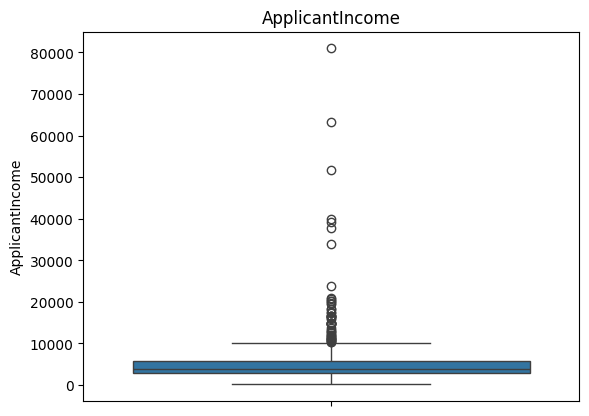

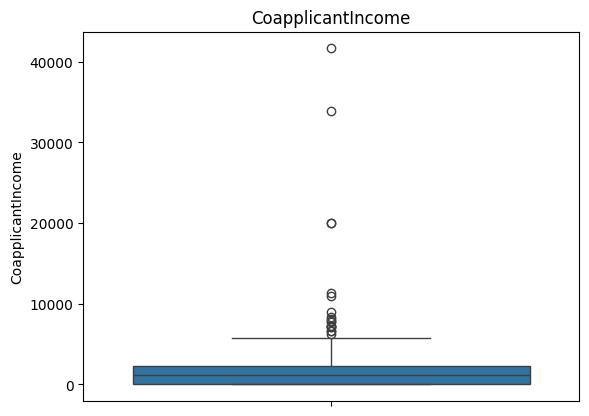

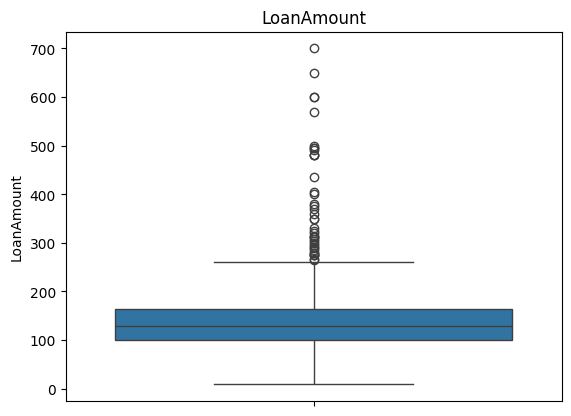

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
num_cols2=['ApplicantIncome','CoapplicantIncome','LoanAmount']
for col in num_cols2:
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()



### **Handling the outliers through IQR method**

### **making sure our values fit exactly between lower bound and upper bound**

In [12]:
for col in num_cols2:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])

### **Checking if we handled the outliers perfectly by calling boxplot again**

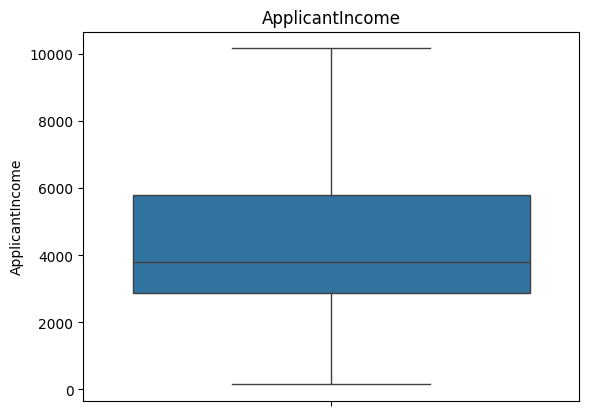

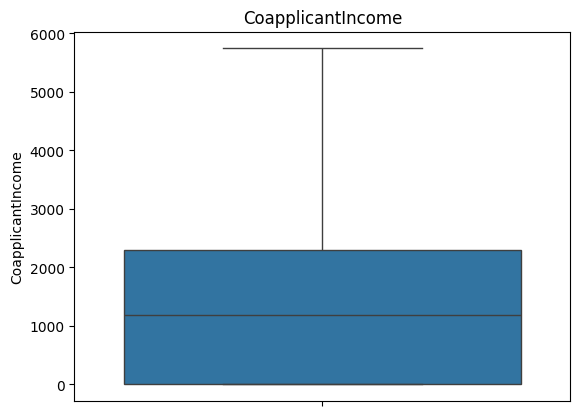

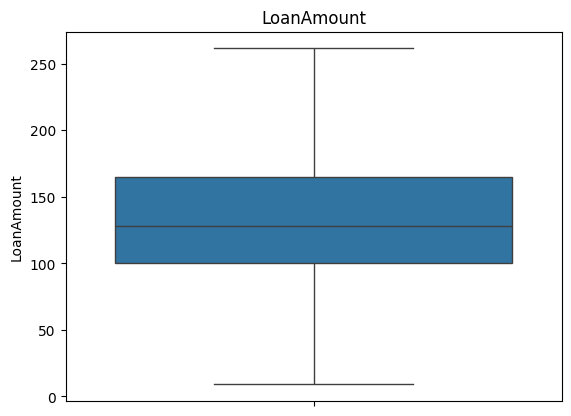

In [13]:
for col in num_cols2:
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()

In [14]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900.0,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106.0,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072.0,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583.0,0.0,187.0,360.0,1.0,Urban,Y


## **Encoding**

### **Importing LabelEncoder from sklearn**

### **Dropping the column Loan_ID since it is an identifier and has no predictive value**

### **Transforming binary categorical columns to numerical by label encoding**

In [15]:
from sklearn.preprocessing import LabelEncoder
if 'Loan_ID' in df.columns:
    df = df.drop(columns=['Loan_ID'])
le = LabelEncoder()
binary_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Loan_Status']
for col in binary_cols:
    df[col] = le.fit_transform(df[col])


### **Converting 3+ to 3 to make it clean in Dependents coulmn**

In [18]:
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

### **Property_Area is a nominal column with more than two values, so I'm using One-hot encoding method**

### **Dropping the first column produced by get_dummies by setting drop_first=True to prevent dummy variable trap**

### **Since get_dummies() provide boolean values(True/False), converting it into integers using astype()**

In [17]:
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)
df = df.astype({col: int for col in df.columns if df[col].dtype == 'bool'})

### **New encoded dataframe**

In [19]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,0,5849.0,0.0,128.0,360.0,1.0,1,0,1
1,1,1,1,0,0,4583.0,1508.0,128.0,360.0,1.0,0,0,0
2,1,1,0,0,1,3000.0,0.0,66.0,360.0,1.0,1,0,1
3,1,1,0,1,0,2583.0,2358.0,120.0,360.0,1.0,1,0,1
4,1,0,0,0,0,6000.0,0.0,141.0,360.0,1.0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,2900.0,0.0,71.0,360.0,1.0,1,0,0
610,1,1,3,0,0,4106.0,0.0,40.0,180.0,1.0,1,0,0
611,1,1,1,0,0,8072.0,240.0,253.0,360.0,1.0,1,0,1
612,1,1,2,0,0,7583.0,0.0,187.0,360.0,1.0,1,0,1


## **Scaling**

### **Importing StandardScaler from sklearn**

### **Splitting the columns and scaling only continuous numerical columns**

In [28]:
from sklearn.preprocessing import StandardScaler
X = df[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']]
y = df['Loan_Status']

scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)
df[X.columns] = X_scaled
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,0,0.497164,-0.874587,-0.168041,360.0,1.0,1,0,1
1,1,1,1,0,0,-0.013767,0.054395,-0.168041,360.0,1.0,0,0,0
2,1,1,0,0,1,-0.652632,-0.874587,-1.280462,360.0,1.0,1,0,1
3,1,1,0,1,0,-0.820924,0.578025,-0.311579,360.0,1.0,1,0,1
4,1,0,0,0,0,0.558104,-0.874587,0.065209,360.0,1.0,1,0,1


### **Data became standardized with a mean of 0 and a standard deviation of 1 through the continuous numerical columns**

In [31]:
round(df.describe())

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
count,614.0,614.0,614.0,614.0,614.0,614.0,614.0,614.0,614.0,614.0,614.0,614.0,614.0
mean,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,342.0,1.0,1.0,0.0,0.0
std,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,64.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,-2.0,-1.0,-2.0,12.0,0.0,0.0,0.0,0.0
25%,1.0,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,360.0,1.0,0.0,0.0,0.0
50%,1.0,1.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,360.0,1.0,1.0,0.0,0.0
75%,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,360.0,1.0,1.0,1.0,1.0
max,1.0,1.0,3.0,1.0,1.0,2.0,3.0,2.0,480.0,1.0,1.0,1.0,1.0


# **Final scaled data**

In [32]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,0,0.497164,-0.874587,-0.168041,360.0,1.0,1,0,1
1,1,1,1,0,0,-0.013767,0.054395,-0.168041,360.0,1.0,0,0,0
2,1,1,0,0,1,-0.652632,-0.874587,-1.280462,360.0,1.0,1,0,1
3,1,1,0,1,0,-0.820924,0.578025,-0.311579,360.0,1.0,1,0,1
4,1,0,0,0,0,0.558104,-0.874587,0.065209,360.0,1.0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,-0.692990,-0.874587,-1.190750,360.0,1.0,1,0,0
610,1,1,3,0,0,-0.206274,-0.874587,-1.746961,180.0,1.0,1,0,0
611,1,1,1,0,0,1.394319,-0.726739,2.074743,360.0,1.0,1,0,1
612,1,1,2,0,0,1.196969,-0.874587,0.890553,360.0,1.0,1,0,1
